In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
caminho_arquivo = "dataset/iris_dataset.xlsx"

In [3]:
df = pd.read_excel(caminho_arquivo)

In [4]:
display(df.head())

,meas1,meas2,meas3,meas4,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
print("Contagem de amostras por classe:")
print(df.value_counts(df.columns[-1]))

Contagem de amostras por classe:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [6]:
np.random.seed(42)

k_pastas = 5

classes = df['species'].unique()

In [7]:
fatias_por_classe = {}

for flor in classes:
    indices = df[df['species'] == flor].index.to_numpy().copy()

    np.random.shuffle(indices)

    fatias = np.array_split(indices, k_pastas)
    fatias_por_classe[flor] = fatias

In [8]:
pastas_teste = []

for i in range(k_pastas):
    indices_teste = np.concatenate(
        [fatias_por_classe[flor][i] for flor in classes])
    pastas_teste.append(indices_teste)

print(f"Total de pastas criadas: {len(pastas_teste)}\n")

for i, indices in enumerate(pastas_teste):
    amostras_desta_pasta = df.loc[indices]

    print(f"Pasta {i+1}")
    print(f"Total de amostras: {len(indices)}")
    print(amostras_desta_pasta['species'].value_counts().to_string())
    print("\n")

Total de pastas criadas: 5

Pasta 1
Total de amostras: 30
species
setosa        10
versicolor    10
virginica     10


Pasta 2
Total de amostras: 30
species
setosa        10
versicolor    10
virginica     10


Pasta 3
Total de amostras: 30
species
setosa        10
versicolor    10
virginica     10


Pasta 4
Total de amostras: 30
species
setosa        10
versicolor    10
virginica     10


Pasta 5
Total de amostras: 30
species
setosa        10
versicolor    10
virginica     10




In [9]:
class GaussianNaiveBayes:
    def __init__(self):
        self.parametros = {}
        self.classes = None

    def fit(self, X, y):
        self.classes = np.unique(y)

        for c in self.classes:
            X_c = X[y == c]
            self.parametros[c] = {
                'media': np.mean(X_c, axis=0),
                'variancia': np.var(X_c, axis=0),
                'prior': X_c.shape[0] / X.shape[0]
            }

    def _calcular_verossimilhanca(self, media, variancia, x):
        eps = 1e-6
        coeficiente = 1.0 / np.sqrt(2.0 * np.pi * variancia + eps)
        expoente = np.exp(-((x - media) ** 2) / (2 * variancia + eps))
        return coeficiente * expoente

    def predict(self, X):
        y_pred = []

        for x in X:
            probabilidades_posteriores = []

            for c in self.classes:
                prior = np.log(self.parametros[c]['prior'])

                verossimilhanca = np.sum(np.log(self._calcular_verossimilhanca(
                    self.parametros[c]['media'], self.parametros[c]['variancia'], x)))

                posterior = prior + verossimilhanca
                probabilidades_posteriores.append(posterior)

            indice_vencedor = np.argmax(probabilidades_posteriores)
            y_pred.append(self.classes[indice_vencedor])

        return np.array(y_pred)

In [10]:
acuracias = []

colunas_features = ['meas1', 'meas2', 'meas3', 'meas4']

todos_y_reais = []
todos_y_previstos = []

print("Iniciando Validação Cruzada (5-Fold Estratificado)")

for i in range(k_pastas):
    indices_teste = pastas_teste[i]

    indices_treino = np.concatenate(
        [pastas_teste[j] for j in range(k_pastas) if j != i])

    X_treino = df.loc[indices_treino, colunas_features].to_numpy()
    y_treino = df.loc[indices_treino, 'species'].to_numpy()

    X_teste = df.loc[indices_teste, colunas_features].to_numpy()
    y_teste = df.loc[indices_teste, 'species'].to_numpy()

    modelo = GaussianNaiveBayes()
    modelo.fit(X_treino, y_treino)

    previsoes = modelo.predict(X_teste)

    todos_y_reais.extend(y_teste)
    todos_y_previstos.extend(previsoes)

    acertos = np.sum(previsoes == y_teste)
    total = len(y_teste)
    acuracia = acertos / total
    acuracias.append(acuracia)

    print(f"Rodada {i+1}:")
    print(f"    Treino: {len(y_treino)} flores | Teste {len(y_teste)} flores")
    print(
        f"    Acertos: {acertos} de {total} -> Acurácia: {acuracia * 100:.2f}%")
    print("\n")

acuracia_media = np.mean(acuracias)
desvio_padrao = np.std(acuracias)

print("Resultado Final:")
print(
    f"Acuracia Media: {acuracia_media * 100:.2f}% (+- {desvio_padrao * 100:.2f}%)")

print("Matriz de Confusão Global (150 Amostras)")
matriz_confusao = pd.crosstab(
    pd.Series(todos_y_reais, name='Real'),
    pd.Series(todos_y_previstos, name='Previsto')
)
display(matriz_confusao)

Iniciando Validação Cruzada (5-Fold Estratificado)
Rodada 1:
    Treino: 120 flores | Teste 30 flores
    Acertos: 29 de 30 -> Acurácia: 96.67%


Rodada 2:
    Treino: 120 flores | Teste 30 flores
    Acertos: 29 de 30 -> Acurácia: 96.67%


Rodada 3:
    Treino: 120 flores | Teste 30 flores
    Acertos: 29 de 30 -> Acurácia: 96.67%


Rodada 4:
    Treino: 120 flores | Teste 30 flores
    Acertos: 28 de 30 -> Acurácia: 93.33%


Rodada 5:
    Treino: 120 flores | Teste 30 flores
    Acertos: 29 de 30 -> Acurácia: 96.67%


Resultado Final:
Acuracia Media: 96.00% (+- 1.33%)
Matriz de Confusão Global (150 Amostras)


Previsto,setosa,versicolor,virginica
Real,,,
setosa,50,0,0
versicolor,0,47,3
virginica,0,3,47


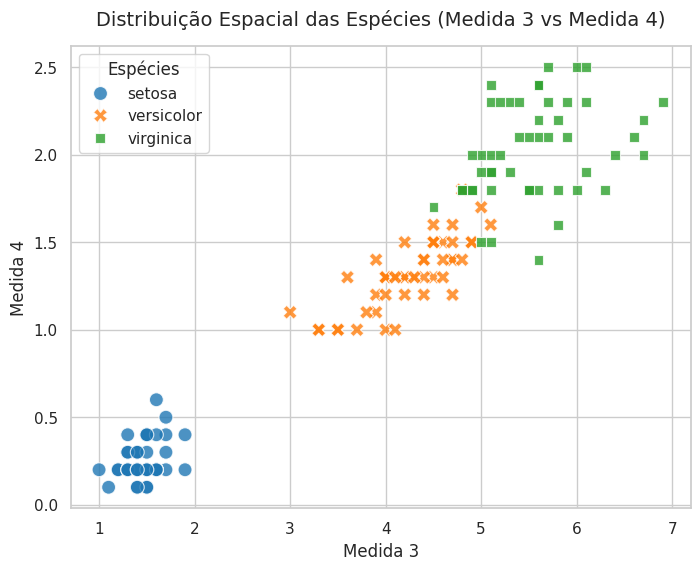

In [11]:
plt.figure(figsize=(8,6))
sns.set_theme(style='whitegrid')

sns.scatterplot(
    data=df,
    x='meas3',
    y='meas4',
    hue='species',
    palette=['#1f77b4', '#ff7f0e', '#2ca02c'],
    style='species',
    s=100,
    alpha=0.8
)

plt.title('Distribuição Espacial das Espécies (Medida 3 vs Medida 4)', fontsize=14, pad=15)
plt.xlabel('Medida 3', fontsize=12)
plt.ylabel('Medida 4', fontsize=12)
plt.legend(title='Espécies')

plt.show()